In [1]:
import sys

sys.path.append("../src/")

from constants import INPT_VARS, EXTRA_VARS, OUT_VARS
from hydra.utils import instantiate
from pathlib import Path
import os
from matplotlib.animation import FuncAnimation

from utils.train_utils import extract_wet
from utils.data_utils import (
    get_train_test_ranges,
    data_CNN_Disk,
    data_CNN_Disk_steps,
    gen_3D_data,
)
from utils.eval_utils import (
    generate_model_rollout,
    compute_KE,
    compute_nino34,
    compute_amo,
    gen_KE_range,
    gen_value_range,
    compute_mean_single,
)
from utils.climate_utils import compute_laplacian_wet

import numpy as np
import torch
import xarray as xr
import copy

from hydra import compose, initialize_config_dir
import copy
from datetime import datetime
import os

In [2]:
########################################################

# All Levels - v0.2.1, Hist = 1, hfds_cuminteg, No Fast ins/outs
with initialize_config_dir(
    version_base=None,
    config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs",
):
    args = compose(
        config_name="exp/eval_unet_global_3D_all_hfds_cuminteg_1975",
        overrides=[
            "output_dir=./temp/{0}_ConvNextUNetTrain3Dv021Eval3DhfdscumintegNofastinoutEpochs70Epoch55_LongRollout0_5Wm2annualincrease_detrendhfdsearlyonly".format(
                str(datetime.now())[:10]
            ),
            "network={0}_ConvNextUNetTrain3Dv021Eval3DhfdscumintegNofastinoutEpochs70Epoch55_LongRollout0_5Wm2annualincrease_detrendhfdsearlyonly".format(
                str(datetime.now())[:10]
            ),
            "ckpt_path=['/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train_3D/send_to_perlmutter/cuminteghfds/seeds/convnextunet_epoch_55_beststeps_4_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth.pt']",
            "hist=1",
            "unet.ch_width=[157,200,250,300,400]",
            "run_gen_pred=True",
            "pred_names=null",
            "pred_paths=null",
            "N_samples=0",
            "N_val=0",
            "N_test=7300",
            "+save_factor=200",
            "exp_num_in=3D_noFast_all",
            "exp_num_out=3D_noFast_all",
            "+dataset_name=OM4",
            "train_region=global_3D",
            "region=global_3D",
            "model_name_replace=Convnext",
            "depth_mode=all",
        ],
    )

########################################################

# All Levels - v0.2.1, Hist = 1, hfds_cuminteg
# with initialize_config_dir(
#     version_base=None,
#     config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs/exp",
# ):
#     args = compose(
#         config_name="exp/eval_unet_global_3D_all_hfds_cuminteg_1975",
#         overrides=[
#             "output_dir=./temp/{0}_ConvNextUNetTrain3Dv021Eval3DhfdscumintegEpochs70Epoch55_seed10".format(
#                 str(datetime.now())[:10]
#             ),
#             "network={0}_ConvNextUNetTrain3Dv021Eval3DhfdscumintegEpochs70Epoch55_seed10".format(
#                 str(datetime.now())[:10]
#             ),
#             "ckpt_path=['']",
#             "hist=1",
#             "unet.ch_width=[157,200,250,300,400]",
#             "run_gen_pred=True",
#             "pred_names=null",
#             "pred_paths=null",
#             "N_samples=2850",
#             "N_val=50",
#             "N_test=600",
#             "+dataset_name=OM4",
#             "train_region=global_3D",
#             "region=global_3D",
#             "model_name_replace=Convnext",
#             "depth_mode=all",
#         ],
#     )

In [3]:
inputs_str = INPT_VARS[args.exp_num_in]
extra_in_str = EXTRA_VARS[args.exp_num_extra]
outputs_str = OUT_VARS[args.exp_num_out]
levels = args.exp_num_in.split("_")[-1]
if "all" in levels:
    levels = 19
elif "2D" in levels:
    levels = 1
else:
    levels = int(levels)

str_in = "".join([i + "_" for i in inputs_str])
str_ext = "".join([i + "_" for i in extra_in_str])
str_out = "".join([i + "_" for i in outputs_str])

print("inputs: " + str_in)
print("extra inputs: " + str_ext)
print("outputs: " + str_out)
print("levels: " + str(levels))

N_atm = len(extra_in_str)  # Number of atmosphere variables
N_in = len(inputs_str)
if args.lateral:
    N_extra = (
        N_atm + N_in
    )  # Number of atmosphere variables + Lateral boundary variables
else:
    N_extra = N_atm  # Number of atmosphere variables
N_out = len(outputs_str)

num_in = int((args.hist + 1) * N_in + N_extra)
num_out = int((args.hist + 1) * len(outputs_str))

print("Number of inputs: ", num_in)  # 3 (ocean speeds + ocean temp)(t) +
# 3 (atm wind stresses + atm temp)(t) +
# 3 (boundary ocean speeds + boundary ocean temp)(t) -> 3 (ocean speeds + ocean temp)(t+1)
print("Number of outputs: ", num_out)  # 3

if "swin" in args.network.lower():
    pass
    # model = instantiate(
    #     args.swin,
    #     in_channels=num_in,
    #     output_channels=num_out,
    #     pretrain_img_size=[180, 360],
    #     wet=wet.cuda(),
    #     hist=args.hist,
    # )
elif "convnext" in args.network.lower():
    if args.unet.ch_width[0] != num_in:
        print(
            "Changing ch_width to match number of inputs {0} -> {1}".format(
                args.unet.ch_width[0], num_in
            )
        )
        args.unet.ch_width[0] = num_in

# Post-fix strings
str_train = (
    "steps_"
    + str(args.steps)
    + "_"
    + args.train_region
    + "_"
    + args.depth_mode
    + "_N_train_4000"
    + "_Lateral_Data_025_no_smooth"
)
str_save = (
    "steps_"
    + str(args.steps)
    + "_"
    + args.train_region
    + "_"
    + args.region
    + "_"
    + args.depth_mode
    + "+N_samples_"
    + str(args.N_samples)
)
post_model_name = (
    "Train_"
    + args.train_region
    + "_Test_"
    + args.region
    + "_"
    + args.depth_mode
    + "_N_train_"
    + str(args.N_samples)
    + "_Lateral_Data_025_no_smooth"
)
post_pred_name = (
    args.region + "_" + args.depth_mode + "_N_samples_" + str(args.N_samples)
)

# Getting start and end indices of train and test
s_train, e_train, e_test = get_train_test_ranges(
    args.N_samples, args.N_val, args.lag, args.hist, args.interval
)
dataset_name = args.dataset_name

if "OM4" in dataset_name:
    timestep_str = "\\times 5"
else:
    raise ValueError("Dataset not recognized")


print("Calculating mask tensors")
wet_zarr = xr.open_zarr(os.path.join("/vast/sd5313/data/m2lines/3D_ocean_data", args.wet_file))
wet = extract_wet(wet_zarr, outputs_str, args.hist)
print("Wet resolution:", wet.shape)
print("e_test: ", e_test)

inputs: thetao_lev_2_5_thetao_lev_10_0_thetao_lev_22_5_thetao_lev_40_0_thetao_lev_65_0_thetao_lev_105_0_thetao_lev_165_0_thetao_lev_250_0_thetao_lev_375_0_thetao_lev_550_0_thetao_lev_775_0_thetao_lev_1050_0_thetao_lev_1400_0_thetao_lev_1850_0_thetao_lev_2400_0_thetao_lev_3100_0_thetao_lev_4000_0_thetao_lev_5000_0_thetao_lev_6000_0_so_lev_2_5_so_lev_10_0_so_lev_22_5_so_lev_40_0_so_lev_65_0_so_lev_105_0_so_lev_165_0_so_lev_250_0_so_lev_375_0_so_lev_550_0_so_lev_775_0_so_lev_1050_0_so_lev_1400_0_so_lev_1850_0_so_lev_2400_0_so_lev_3100_0_so_lev_4000_0_so_lev_5000_0_so_lev_6000_0_zos_
extra inputs: tauuo_tauvo_cum_integrated_heat_
outputs: thetao_lev_2_5_thetao_lev_10_0_thetao_lev_22_5_thetao_lev_40_0_thetao_lev_65_0_thetao_lev_105_0_thetao_lev_165_0_thetao_lev_250_0_thetao_lev_375_0_thetao_lev_550_0_thetao_lev_775_0_thetao_lev_1050_0_thetao_lev_1400_0_thetao_lev_1850_0_thetao_lev_2400_0_thetao_lev_3100_0_thetao_lev_4000_0_thetao_lev_5000_0_thetao_lev_6000_0_so_lev_2_5_so_lev_10_0_so_lev_22

In [4]:
import xarray as xr
import numpy as np
import torch
import torch.nn as nn
import torch.utils.data as data
from scipy.ndimage import gaussian_filter
from einops import rearrange
import os

class data_CNN_Disk(torch.utils.data.Dataset):

    def __init__(
        self,
        data,
        inputs_str,
        extra_in_str,
        outputs_str,
        wet,
        data_mean,
        data_std,
        n_samples,
        lag,
        interval,
        hist,
        ind_start,
        long_rollout,
        device="cuda",
    ):
        super().__init__()
        self.device = device

        self.size = n_samples
        self.lag = lag
        self.interval = interval
        self.hist = hist
        self.ind_start = ind_start

        assert self.interval == 1
        assert self.lag == 1

        data = data.isel(time=slice(self.ind_start, None))
        self.inputs = data[inputs_str + extra_in_str]
        self.outputs = data[outputs_str]
        self.inputs_no_extra = data[inputs_str]
        self.extras = data[extra_in_str]

        # This class will be used only for validation and rollouts
        # Rolling indices to keep track of histories/past states:
        # HIST=0 ; 0->[0, 1]; 1->[1, 2]; 2->[2, 3]; 3->[3, 4]
        # HIST=1 ; 0->[[0, 1], [2, 3]]; 1->[[2, 3], [4, 5]]; 2->[[4, 5], [6, 7]]; 3->[[6, 7], [8, 9]]
        # HIST=2 ; 0->[[0, 1, 2], [3, 4, 5]]; 1->[[3, 4, 5], [6, 7, 8]]; 2->[[6, 7, 8], [9, 10, 11]]; 3->[[9, 10, 11], [12, 13, 14]]
        indices = xr.DataArray(
            np.arange(data.time.size),
            dims=["time"],
            coords={"time": data.time},
        )
        total_steps = 2 * self.hist + 1
        rolling_indices = (
            indices.rolling(time=len(data.time) - total_steps, center=False)
            .construct("window_dim")
            .astype(int)
        )
        rolling_indices = rolling_indices.transpose("window_dim", "time").isel(
            time=slice(len(data.time) - total_steps - 1, None)
        )  # Remove first few null indices
        self.rolling_indices = rolling_indices.isel(
            window_dim=slice(0, None, self.hist + 1)
        )  # Skip indices based on history

        if long_rollout:
            window0 = self.rolling_indices.isel(window_dim=0)
            print(
                "Long rollout will begin with input and produce output from time index {0} and {1} respectively".format(
                    window0.isel(time=0).values + ind_start,
                    window0.isel(time=self.hist + 1).values + ind_start,
                )
            )

        self.in_mean = data_mean[inputs_str + extra_in_str]
        self.in_std = data_std[inputs_str + extra_in_str]
        self.out_mean = data_mean[outputs_str]
        self.out_std = data_std[outputs_str]
        self.inputs_no_extra_mean = data_mean[inputs_str]
        self.inputs_no_extra_std = data_std[inputs_str]
        self.extras_mean = data_mean[extra_in_str]
        self.extras_std = data_std[extra_in_str]

        self.wet = wet

    def set_device(self, device):
        self.device = device

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        if type(idx) == slice:
            if idx.start == None and idx.stop == None:
                idx = slice(0, self.size, idx.step)
            elif idx.start == None:
                idx = slice(0, idx.stop, idx.step)
            elif idx.stop == None:
                idx = slice(idx.start, self.size, idx.step)
        elif type(idx) == int:
            idx = slice(idx, idx + 1, 1)

        rolling_idx = self.rolling_indices.isel(window_dim=idx)
        x_index = xr.Variable(
            ["window_dim", "time"], rolling_idx
        )
        print("Out: ", (self.ind_start + x_index.isel(time=slice(self.hist + 1, None))).values, end=' ')
        data_in = self.inputs_no_extra.isel(time=x_index).isel(
            time=slice(None, self.hist + 1)
        )
        data_in = (
            (data_in - self.inputs_no_extra_mean) / self.inputs_no_extra_std
        ).fillna(0)
        data_in = (
            data_in.to_array()
            .transpose("window_dim", "time", "variable", "y", "x")
            .to_numpy()
        )
        data_in = rearrange(
            data_in, "window_dim time variable y x -> window_dim (time variable) y x"
        )
        if len(self.extras.variables) != 0:
            data_in_boundary = self.extras.isel(time=x_index).isel(time=self.hist)
            data_in_boundary = (
                (data_in_boundary - self.extras_mean) / self.extras_std
            ).fillna(0)
            data_in_boundary = (
                data_in_boundary.to_array()
                .transpose("window_dim", "variable", "y", "x")
                .to_numpy()
            )
            data_in = np.concatenate((data_in, data_in_boundary), axis=1)

        label = self.outputs.isel(time=x_index).isel(time=slice(self.hist + 1, None))
        label = ((label - self.out_mean) / self.out_std).fillna(0)
        label = (
            label.to_array()
            .transpose("window_dim", "time", "variable", "y", "x")
            .to_numpy()
        )
        label = rearrange(
            label, "window_dim time variable y x -> window_dim (time variable) y x"
        )

        items = (torch.from_numpy(data_in).float(), torch.from_numpy(label).float())

        return items

In [5]:
data = xr.open_zarr(os.path.join("/vast/sd5313/data/m2lines/3D_ocean_data", args.data_zarr))

In [6]:
data = data.sel(time=slice("1990-01-01", "1999-12-31"))

In [7]:
poly_coeffs = data['hfds'].polyfit(dim='time', deg=1).compute()
trend = xr.polyval(data['time'], poly_coeffs.polyfit_coefficients).compute()

# Remove the trend from the original data
data['hfds'] = (data['hfds'] - trend).compute()

In [8]:
repeats = 40
data = xr.concat([data] * repeats, dim="time")
data['time'] = np.arange(data.time.size)
data

<xarray.Dataset>
Dimensions:              (y: 180, x: 360, time: 29200, lev: 19, y_b: 181,
                          x_b: 361)
Coordinates:
    areacello            (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    dz                   (lev) int64 dask.array<chunksize=(19,), meta=np.ndarray>
    lat                  (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lat_b                (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
  * lev                  (lev) float64 2.5 10.0 22.5 40.0 ... 4e+03 5e+03 6e+03
    lon                  (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lon_b                (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
    ocean_fraction       (lev, y, x) float64 dask.array<chunksize=(19, 180, 360), meta=np.ndarray>
  * time                 (time) int64 0 1 2 3 4 ... 29196 29197 29198 29199
    wetmask              (lev, y, x) bool dask.array<chunksize=(10, 90, 360), meta=np.ndarray>
  * x                    (x) float64 0.5 1.5 2.5 3.5 ... 356.5 357.5 358.5 359.5
  * y                    (y) float64 -89.24 -88.25 -87.25 ... 87.25 88.25 89.24
Dimensions without coordinates: y_b, x_b
Data variables: (12/81)
    cum_integrated_heat  (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    hfds                 (time, y, x) float64 nan nan nan ... 0.9097 0.9184
    so_lev_1050_0        (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_105_0         (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_10_0          (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_1400_0        (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    ...                   ...
    vo_lev_5000_0        (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_550_0         (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_6000_0        (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_65_0          (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_775_0         (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    zos                  (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes:
    m2lines/ocean-emulators_git_hash:  https://github.com/m2lines/ocean_emula...
    regrid_method:                     conservative

In [10]:
var = 'hfds'
old_hfds = data[var].copy()
assert ((old_hfds.fillna(0).values == data[var].fillna(0).values).all())
data[var] = data[var] + np.reshape(np.arange(data[var].time.size)* (0.0136986301/2),(-1,1,1))
assert not ((old_hfds.fillna(0).values == data[var].fillna(0).values).all())

In [11]:
from scipy.integrate import cumulative_trapezoid
import dask
a = cumulative_trapezoid(data["hfds"].values, axis=0, initial=0)
data['cum_integrated_heat'] = (['time', 'y', 'x'], dask.array.from_array(a, chunks=(1,180,360)))

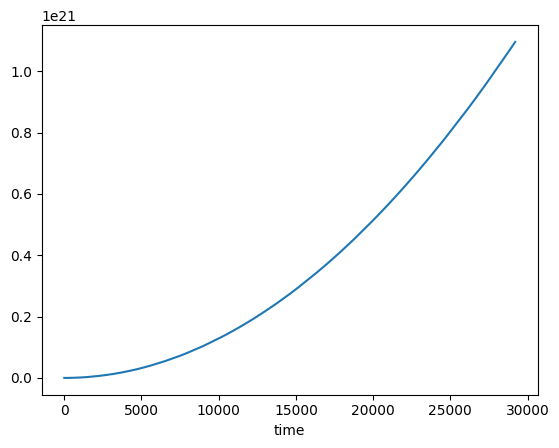

In [12]:
cum_hfds_timeseries = (data['cum_integrated_heat']*data['areacello']).sum(['x', 'y'])
cum_hfds_timeseries.plot()

In [16]:

data_mean = xr.open_zarr(
    os.path.join("/vast/sd5313/data/m2lines/3D_ocean_data", args.data_means_zarr)
)
data_std = xr.open_zarr(
    os.path.join("/vast/sd5313/data/m2lines/3D_ocean_data", args.data_stds_zarr)
)
train_data = data_CNN_Disk_steps(
    data,
    inputs_str,
    extra_in_str,
    outputs_str,
    wet,
    data_mean,
    data_std,
    args.N_samples,
    args.lag,
    args.interval,
    args.hist,
    args.steps,
    device="cuda",
)

test_data = data_CNN_Disk(
    data,
    inputs_str,
    extra_in_str,
    outputs_str,
    wet,
    data_mean,
    data_std,
    data.time.size,
    args.lag,
    args.interval,
    args.hist,
    e_test,
    long_rollout=True,
    device="cuda",
)
# test_data[0]



Long rollout will begin with input and produce output from time index 1 and 3 respectively


/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:188: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


In [17]:
# Model
print("Loading model " + args.network)
if "swin" in args.network.lower():
    model = instantiate(
        args.swin,
        in_channels=num_in,
        output_channels=num_out,
        pretrain_img_size=[180, 360],
        wet=wet.cuda(),
        hist=args.hist,
    )
elif "unet" in args.network.lower():
    model = instantiate(args.unet, n_out=num_out, wet=wet.cuda(), hist=args.hist)

full_model_path = args.ckpt_path
full_model_name = args.network + "_" + post_model_name
output_channels = model.output_channels

model = model.to(args.device)
ckpt_path = args.ckpt_path
model = model

# Stats
mean_in = test_data.in_mean.to_array().to_numpy().reshape(-1)
std_in = test_data.in_std.to_array().to_numpy().reshape(-1)
mean_out = test_data.out_mean.to_array().to_numpy().reshape(-1)
std_out = test_data.out_std.to_array().to_numpy().reshape(-1)

test_data.norm_vals = {
    "s_out": std_out,
    "s_in": std_in,
    "m_out": mean_out,
    "m_in": mean_in,
}

# Getting area tensor
print("Computing area tensor")
grids = xr.open_dataset(os.path.join("/vast/sd5313/data/m2lines/3D_ocean_data", args.grid_file)).rename({"xu_ocean": "x", "yu_ocean": "y"})

area = torch.from_numpy(grids["area_C"].to_numpy()).to(device="cpu")
pred_model_path = Path("/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds") / full_model_name
if not os.path.isdir(pred_model_path):
    os.makedirs(pred_model_path)

Nb = args.Nb
hist = args.hist
lag = args.lag
N_test = args.N_test
N_samples = args.N_samples
output_dir = args.output_dir
region = args.region
steps = args.steps
network = args.model_name_replace

pred_region = args.region
pred_names = args.pred_names if args.pred_names else []
pred_paths = args.pred_paths if args.pred_paths else []

JUPYTER_MODE = False
    
    


Loading model 2024-10-29_ConvNextUNetTrain3Dv021Eval3DhfdscumintegNofastinoutEpochs70Epoch55_LongRollout0_5Wm2annualincrease_detrendhfdsearlyonly
Computing area tensor


In [18]:
out_mean = torch.tensor(test_data.out_mean.to_array().to_numpy()).to(device="cuda")
out_std = torch.tensor(test_data.out_std.to_array().to_numpy()).to(device="cuda")

In [19]:
### Generate
def generate_pred_lateral():
    print("Generation Pred begin...")
    for rand_ind, model_path in enumerate(args.ckpt_path):
        print("Random seed: ", rand_ind + 1)
        # try:
        model.load_state_dict(
            torch.load(model_path, map_location=torch.device("cuda"))["model"]
        )
        # except:
        #     model.load_state_dict(
        #         torch.load(model_path, map_location=torch.device("cuda"))
        #     )
        pred_path = pred_model_path / (
                        "Pred_lateral_Fast_Data_025_"
                        + post_pred_name
                        + "_rand_seed_"
                        + str(rand_ind + 1)
                        + ".zarr"
                    )
        save_factor = args.save_factor
        print(f"Using save_factor {save_factor} to produce {N_test // save_factor} steps each iteration")
        outs = None
        if not os.path.isdir(pred_path):
            start = 0
            print(f"Starting save from {start} for Pred path {pred_path}")
            initial_input = None
        else:
            pred = xr.open_zarr(pred_path)
            start = pred.time.size
            print(f"Restarting save from {start} for Pred path {pred_path}")
            last_pred_numpy = pred.isel(time=slice(-2,None)).to_array().to_numpy().squeeze()
            last_pred = torch.tensor(last_pred_numpy).to(device="cuda")
            assert last_pred.shape[:3] == torch.Size([2, 180, 360])
            last_pred = (last_pred - out_mean) / out_std
            initial_input = torch.swapaxes(torch.swapaxes(last_pred, 3, 2), 2, 1).reshape(-1, 180, 360)
            

        for i in range(start, N_test, N_test // save_factor):
            start_time = time.time()
            test_data = data_CNN_Disk(
                data,
                inputs_str,
                extra_in_str,
                outputs_str,
                wet,
                data_mean,
                data_std,
                args.N_test,
                args.lag,
                args.interval,
                args.hist,
                e_test + i,
                long_rollout=True,
                device="cuda",
            )
            
            test_data.norm_vals = {
                "s_out": std_out,
                "s_in": std_in,
                "m_out": mean_out,
                "m_in": mean_in,
            }
            if outs is not None:
                initial_input = outs[-1]
                
            model_pred, outs = generate_model_rollout(
                N_test // save_factor,
                test_data,
                model,
                hist,
                N_in,
                N_extra,
                initial_input,
                Nb,
                region,
            )
            da = xr.DataArray(
                data=model_pred,
                dims=["time", "x", "y", "var"],
            )

            if i == 0:
                da.to_zarr(pred_path, mode="w")
            else:
                da.to_zarr(pred_path, mode="a", append_dim="time")
            print("Saved: ", i, " to ", i + N_test // save_factor)
            print(f"Time taken for generating {N_test // save_factor} predictions: {time.time() - start_time} seconds")


In [ ]:
import time 
start_time = time.time()
if args.run_gen_pred:
    generate_pred_lateral()
    
print(f"Time taken for generating {N_test} predictions: {time.time() - start_time} seconds")

Generation Pred begin...
Random seed:  1
Using save_factor 200 to produce 36 steps each iteration
Starting save from 0 for Pred path /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-10-29_ConvNextUNetTrain3Dv021Eval3DhfdscumintegNofastinoutEpochs70Epoch55_LongRollout0_5Wm2annualincrease_detrendhfdsearlyonly_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr


/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:188: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


Long rollout will begin with input and produce output from time index 1 and 3 respectively
Out:  [[3 4]] Out:  [[3 4]] Out:  [[5 6]] Out:  [[7 8]] Out:  [[ 9 10]] Out:  [[11 12]] Out:  [[13 14]] Out:  [[15 16]] Out:  [[17 18]] Out:  [[19 20]] Out:  [[21 22]] Out:  [[23 24]] Out:  [[25 26]] Out:  [[27 28]] Out:  [[29 30]] Out:  [[31 32]] Out:  [[33 34]] Out:  [[35 36]] Out:  [[37 38]] Saved:  0  to  36
Time taken for generating 36 predictions: 104.77920627593994 seconds


/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:188: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


Long rollout will begin with input and produce output from time index 37 and 39 respectively
Out:  [[39 40]] Out:  [[39 40]] Out:  [[41 42]] Out:  [[43 44]] Out:  [[45 46]] Out:  [[47 48]] Out:  [[49 50]] Out:  [[51 52]] Out:  [[53 54]] Out:  [[55 56]] Out:  [[57 58]] Out:  [[59 60]] Out:  [[61 62]] Out:  [[63 64]] Out:  [[65 66]] Out:  [[67 68]] Out:  [[69 70]] Out:  [[71 72]] Out:  [[73 74]] Saved:  36  to  72
Time taken for generating 36 predictions: 102.2694160938263 seconds


...

Long rollout will begin with input and produce output from time index 4861 and 4863 respectively
Out:  [[4863 4864]] Out:  [[4863 4864]] Out:  [[4865 4866]] Out:  [[4867 4868]] Out:  [[4869 4870]] Out:  [[4871 4872]] Out:  [[4873 4874]] Out:  [[4875 4876]] Out:  [[4877 4878]] Out:  [[4879 4880]] Out:  [[4881 4882]] Out:  [[4883 4884]] Out:  [[4885 4886]] Out:  [[4887 4888]] Out:  [[4889 4890]] Out:  [[4891 4892]] Out:  [[4893 4894]] Out:  [[4895 4896]] Out:  [[4897 4898]] Saved:  4860  to  4896
Time taken for generating 36 predictions: 97.18701100349426 seconds


/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:188: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


Long rollout will begin with input and produce output from time index 4897 and 4899 respectively
Out:  [[4899 4900]] Out:  [[4899 4900]] Out:  [[4901 4902]] Out:  [[4903 4904]] Out:  [[4905 4906]] Out:  [[4907 4908]] Out:  [[4909 4910]] Out:  [[4911 4912]] Out:  [[4913 4914]] Out:  [[4915 4916]] Out:  [[4917 4918]] Out:  [[4919 4920]] Out:  [[4921 4922]] Out:  [[4923 4924]] Out:  [[4925 4926]] Out:  [[4927 4928]] Out:  [[4929 4930]] Out:  [[4931 4932]] Out:  [[4933 4934]] Saved:  4896  to  4932
Time taken for generating 36 predictions: 101.00304508209229 seconds


/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:188: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


Long rollout will begin with input and produce output from time index 4933 and 4935 respectively
Out:  [[4935 4936]] Out:  [[4935 4936]] Out:  [[4937 4938]] Out:  [[4939 4940]] Out:  [[4941 4942]] 